In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 
from IPython.display import display
import matplotlib.dates as mdates

In [9]:
# Import the dataset
url = 'https://raw.githubusercontent.com/MaharLeika18/DataViz_Activities/refs/heads/main/Lesson%204/Superstore_Sales_Cleaned.csv?token=GHSAT0AAAAAADTZY22YDMV3WDRPNE3ZUNCG2NJI5IA'
df = pd.read_csv(url, index_col=0)

display(df.head(5))

,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Segment,City,State,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Order Date (Month),Profit Margin,YearQuarter
Row ID,,,,,,,,,,,,,,,,,,,,
1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Consumer,Henderson,Kentucky,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,2016-11,16.00,2016Q4
2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Consumer,Henderson,Kentucky,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,2016-11,30.00,2016Q4
3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Corporate,Los Angeles,California,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714,2016-06,47.00,2016Q2
4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Consumer,Fort Lauderdale,Florida,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,2015-10,-40.00,2015Q4
5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Consumer,Fort Lauderdale,Florida,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,2015-10,11.25,2015Q4


In [ ]:
# Fix data types
    # Date Columns set, normalize delimiters first before converting to datetime
df['Order Date'] = df['Order Date'].str.replace("-", "/", regex=False)
df['Order Date'] = pd.to_datetime(df['Order Date'], format='%Y/%m/%d',errors='coerce')

df['Ship Date'] = df['Ship Date'].str.replace("-", "/", regex=False)
df['Ship Date'] = pd.to_datetime(df['Ship Date'], format='%Y/%m/%d', errors='coerce')

    # Numeric Columns set
df['Sales'] = pd.to_numeric(df['Sales'], errors='coerce')
df['Profit'] = pd.to_numeric(df['Profit'], errors='coerce')

    # Categorical Columns set
df['Region'] = df['Region'].astype('category')
df['Category'] = df['Category'].astype('category')
df['Sub-Category'] = df['Sub-Category'].astype('category')

In [ ]:
# Feature Aggregation
    # Sales by Order Date
daily_revenue = (df.groupby(pd.Grouper(key='Order Date', freq='D'))['Sales'].sum().reset_index())
daily_revenue = daily_revenue.sort_values('Order Date')

    # Clamp data to one year for better visualization
daily_revenue = daily_revenue[daily_revenue['Order Date'].dt.year == 2017]

    # Create Moving Averages
daily_revenue['7_day_MA'] = daily_revenue['Sales'].rolling(window=7).mean()
daily_revenue['30_day_MA'] = daily_revenue['Sales'].rolling(window=30).mean()

,Order Date,Sales,7_day_MA,30_day_MA
1094,2017-01-01,1481.828,NaN,NaN
1095,2017-01-02,2079.554,NaN,NaN
1096,2017-01-03,2070.272,NaN,NaN
1097,2017-01-04,0.000,NaN,NaN
1098,2017-01-05,0.000,NaN,NaN
1099,2017-01-06,33.740,NaN,NaN
1100,2017-01-07,3395.590,1294.426286,NaN
1101,2017-01-08,892.980,1210.305143,NaN
1102,2017-01-09,274.491,952.439000,NaN
1103,2017-01-10,0.000,656.685857,NaN


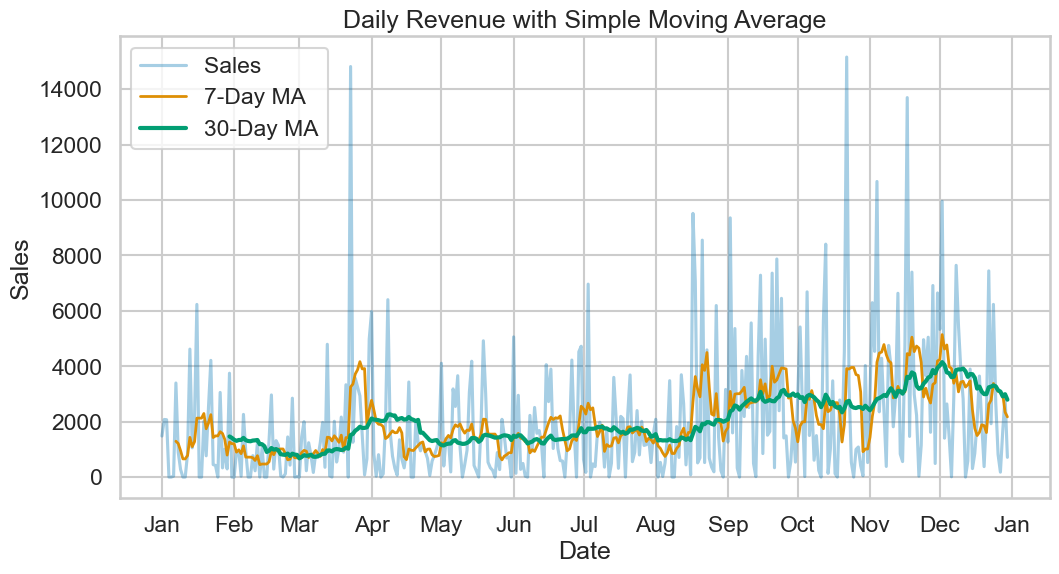

In [26]:
# Triple line-plot (Original, 7-day, 30-day)
    # Convert df into long format for better compatibility with seaborn
plot_df = daily_revenue.melt(
    id_vars='Order Date',
    value_vars=['Sales', '7_day_MA', '30_day_MA'],
    var_name='Metric',
    value_name='Value'
)

sns.set_theme(style="whitegrid", context="talk")
sns.set_palette("colorblind")
plt.figure(figsize=(12,6))

sns.lineplot(data=daily_revenue, x='Order Date', y='Sales', alpha=0.35, label="Sales")
sns.lineplot(data=daily_revenue, x='Order Date', y='7_day_MA', linewidth=2, label="7-Day MA")
sns.lineplot(data=daily_revenue, x='Order Date', y='30_day_MA', linewidth=3, label="30-Day MA")

plt.title('Daily Revenue with Simple Moving Average')
plt.xlabel('Date')
plt.ylabel('Sales')

    # Use formatted date labels
plt.gca().xaxis.set_major_locator(mdates.MonthLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b'))

plt.show()